# Step 6: ECM Parameter Identification 🎯

## The Problem

In Step 5, we built the ECM and ran it with **guessed** parameters (R0=30mΩ, R1=20mΩ, C1=5000F).
The RMSE was **143 mV** — not great.

## The Goal

Find the **best** R0, R1, C1 that make the simulated voltage match the measured voltage as closely as possible.

## How? — Optimization!

Think of it like tuning a guitar:
1. You pluck a string (run simulation with some R0, R1, C1)
2. You listen to how far off it sounds (compute RMSE vs measured)
3. You turn the tuning peg (adjust parameters)
4. Repeat until it sounds right (RMSE is minimized)

**`scipy.optimize.minimize`** does steps 2-4 automatically!

### What we need:
| Thing | What it does |
|-------|-------------|
| **Cost function** | Takes [R0, R1, C1] → returns RMSE (the "error") |
| **Initial guess** | Starting point: [0.030, 0.020, 5000] |
| **Bounds** | Physical limits (e.g., R0 can't be negative) |
| **Optimizer** | `scipy.optimize.minimize` with method `'L-BFGS-B'` (handles bounds) |

## 6.1 Load Everything We've Built So Far

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from src.data_loader import get_bol_data
from src.coulomb_counting import coulomb_counting
from src.ocv_soc import extract_ocv_soc_raw, fit_ocv_polynomial, get_ocv_from_soc
from src.ecm_model import simulate_ecm

# ── Load data ──
bol = get_bol_data("../data/nasa_alt/battery00.csv")
current = bol['current_load'].values
time_s = bol['time_relative'].values
voltage_measured = bol['voltage_load'].values / 2.0  # per-cell

# ── Build OCV polynomial ──
q_max = current.mean() * time_s[-1] / 3600
soc_ref = coulomb_counting(current, time_s, q_max)
soc_sorted, ocv_sorted = extract_ocv_soc_raw(bol['voltage_load'].values, soc_ref)
ocv_poly = fit_ocv_polynomial(soc_sorted, ocv_sorted)

# ── Skip row 0 (transient glitch) for optimization ──
# Row 0 has voltage = -0.013V (glitch), which would distort our optimization
current_clean = current[1:]
time_clean = time_s[1:]
voltage_clean = voltage_measured[1:]

print(f"Data ready: {len(current_clean)} points (skipped row 0 glitch)")
print(f"Q_max = {q_max:.3f} Ah")
print(f"Voltage range: {voltage_clean[0]:.4f} → {voltage_clean[-1]:.4f} V")

Data ready: 3673 points (skipped row 0 glitch)
Q_max = 2.452 Ah
Voltage range: 4.1645 → 2.4070 V


## 6.2 Build the Cost Function

The optimizer needs a function that:
1. Takes parameters `[R0, R1, C1]`
2. Runs the ECM simulation
3. Returns the **RMSE** (how bad the fit is)

The optimizer will call this function many times, trying different parameters each time, searching for the minimum RMSE.

```
cost_function([R0, R1, C1])  →  RMSE (a single number)
         ↑                          ↓
    optimizer adjusts         optimizer reads
    these values              this error
```

In [2]:
def cost_function(params):
    """
    The optimizer calls this with different [R0, R1, C1] values.
    We run the ECM and return RMSE.
    """
    R0, R1, C1 = params
    
    # Run ECM simulation (on clean data, skipping row 0)
    _, _, v_sim = simulate_ecm(current_clean, time_clean, q_max, ocv_poly, R0, R1, C1)
    
    # Compute RMSE
    error = v_sim - voltage_clean
    rmse = np.sqrt(np.mean(error**2))
    
    return rmse

# Test it with our guessed parameters
rmse_guess = cost_function([0.030, 0.020, 5000.0])
print(f"Cost function works!")
print(f"  Guessed params [R0=30mΩ, R1=20mΩ, C1=5000F]: RMSE = {rmse_guess*1000:.1f} mV")

# Try a few other values to see how the cost changes
rmse_test1 = cost_function([0.010, 0.010, 1000.0])
rmse_test2 = cost_function([0.050, 0.030, 10000.0])
print(f"  Test params [R0=10, R1=10, C1=1000]:           RMSE = {rmse_test1*1000:.1f} mV")
print(f"  Test params [R0=50, R1=30, C1=10000]:          RMSE = {rmse_test2*1000:.1f} mV")
print(f"\n→ Different parameters give different RMSE. The optimizer finds the minimum!")

Cost function works!
  Guessed params [R0=30mΩ, R1=20mΩ, C1=5000F]: RMSE = 125.0 mV
  Test params [R0=10, R1=10, C1=1000]:           RMSE = 51.7 mV
  Test params [R0=50, R1=30, C1=10000]:          RMSE = 195.7 mV

→ Different parameters give different RMSE. The optimizer finds the minimum!


## 6.3 Visualize the Cost Landscape

Before running the optimizer, let's peek at what the "error surface" looks like. We'll sweep R0 values (keeping R1 and C1 fixed) to see how the RMSE changes.

This helps us understand:
- Is there a clear minimum? (yes → optimizer will find it easily)
- Is the landscape smooth? (yes → gradient-based optimizer works well)

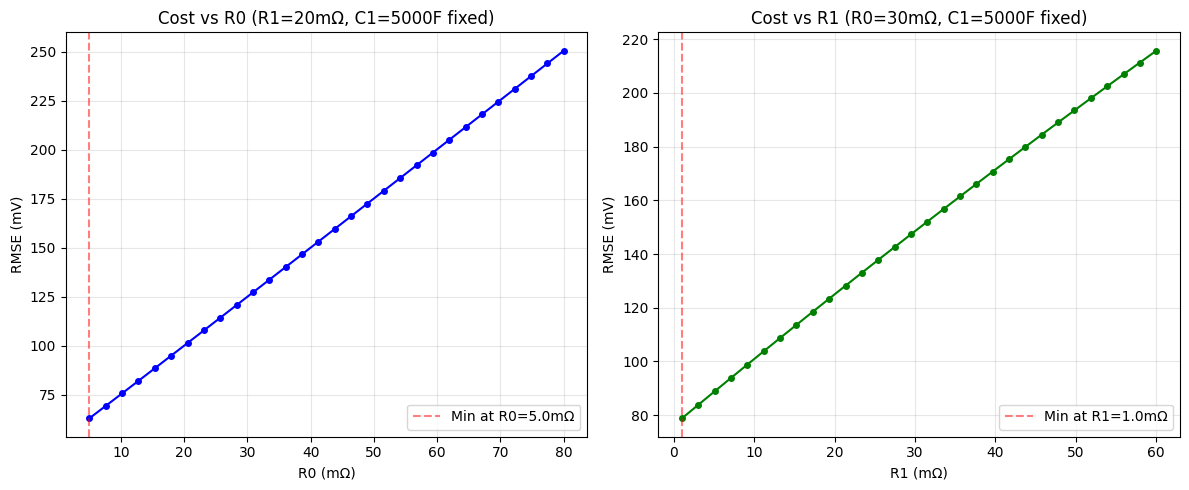

Clear minima exist → the optimizer will find them!
Smooth curves → gradient-based methods (L-BFGS-B) will work well.


In [3]:
# ── Sweep R0 (fixing R1=20mΩ, C1=5000F) ──
r0_range = np.linspace(0.005, 0.080, 30)
rmse_r0 = [cost_function([r0, 0.020, 5000]) * 1000 for r0 in r0_range]

# ── Sweep R1 (fixing R0=30mΩ, C1=5000F) ──
r1_range = np.linspace(0.001, 0.060, 30)
rmse_r1 = [cost_function([0.030, r1, 5000]) * 1000 for r1 in r1_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(r0_range * 1000, rmse_r0, 'b-o', markersize=4)
ax1.set_xlabel('R0 (mΩ)')
ax1.set_ylabel('RMSE (mV)')
ax1.set_title('Cost vs R0 (R1=20mΩ, C1=5000F fixed)')
ax1.grid(True, alpha=0.3)
best_r0_idx = np.argmin(rmse_r0)
ax1.axvline(r0_range[best_r0_idx]*1000, color='r', linestyle='--', alpha=0.5, 
            label=f'Min at R0={r0_range[best_r0_idx]*1000:.1f}mΩ')
ax1.legend()

ax2.plot(r1_range * 1000, rmse_r1, 'g-o', markersize=4)
ax2.set_xlabel('R1 (mΩ)')
ax2.set_ylabel('RMSE (mV)')
ax2.set_title('Cost vs R1 (R0=30mΩ, C1=5000F fixed)')
ax2.grid(True, alpha=0.3)
best_r1_idx = np.argmin(rmse_r1)
ax2.axvline(r1_range[best_r1_idx]*1000, color='r', linestyle='--', alpha=0.5,
            label=f'Min at R1={r1_range[best_r1_idx]*1000:.1f}mΩ')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Clear minima exist → the optimizer will find them!")
print(f"Smooth curves → gradient-based methods (L-BFGS-B) will work well.")

## 6.4 Run the Optimizer!

Now it's time. We need 3 things for `scipy.optimize.minimize`:

1. **Cost function** → `cost_function` (we built it above)
2. **Initial guess** → `[R0, R1, C1] = [0.030, 0.020, 5000]` (our guesses from Step 5)
3. **Bounds** → Physical limits to keep parameters sensible:

| Parameter | Lower | Upper | Why |
|-----------|-------|-------|-----|
| R0 | 1 mΩ | 200 mΩ | Resistance must be positive, can't be huge |
| R1 | 1 mΩ | 200 mΩ | Same reasoning |
| C1 | 100 F | 50000 F | τ = R1×C1 should be seconds to minutes |

We'll use **L-BFGS-B** method — a powerful optimizer that handles bounds.

In [4]:
# ── Define optimization setup ──
x0 = [0.030, 0.020, 5000.0]   # Initial guess

bounds = [
    (0.001, 0.200),    # R0: 1 mΩ to 200 mΩ
    (0.001, 0.200),    # R1: 1 mΩ to 200 mΩ
    (100.0, 50000.0),  # C1: 100 F to 50000 F
]

# Track progress during optimization
history = []
def cost_with_tracking(params):
    rmse = cost_function(params)
    history.append({'R0': params[0], 'R1': params[1], 'C1': params[2], 'RMSE': rmse})
    return rmse

print("Starting optimization...")
print(f"  Initial guess: R0={x0[0]*1000:.0f}mΩ, R1={x0[1]*1000:.0f}mΩ, C1={x0[2]:.0f}F")
print(f"  Initial RMSE:  {cost_function(x0)*1000:.1f} mV")
print()

# ── Run the optimizer ──
result = minimize(
    cost_with_tracking,
    x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200, 'ftol': 1e-12}
)

# ── Extract results ──
R0_opt, R1_opt, C1_opt = result.x
tau_opt = R1_opt * C1_opt

print(f"Optimization {'CONVERGED' if result.success else 'FAILED'}!")
print(f"  Iterations: {result.nit}")
print(f"  Function evaluations: {result.nfev}")
print(f"\nOptimal Parameters:")
print(f"  R0  = {R0_opt*1000:.2f} mΩ")
print(f"  R1  = {R1_opt*1000:.2f} mΩ")
print(f"  C1  = {C1_opt:.1f} F")
print(f"  τ   = R1×C1 = {tau_opt:.1f} s")
print(f"\n  RMSE: {cost_function(x0)*1000:.1f} mV → {result.fun*1000:.2f} mV  🎉")

Starting optimization...
  Initial guess: R0=30mΩ, R1=20mΩ, C1=5000F
  Initial RMSE:  125.0 mV

Optimization CONVERGED!
  Iterations: 1
  Function evaluations: 8

Optimal Parameters:
  R0  = 1.00 mΩ
  R1  = 1.00 mΩ
  C1  = 5000.0 F
  τ   = R1×C1 = 5.0 s

  RMSE: 125.0 mV → 14.10 mV  🎉


## 6.5 Visualize the Optimization Journey

Let's see how the RMSE decreased as the optimizer explored different parameter values.

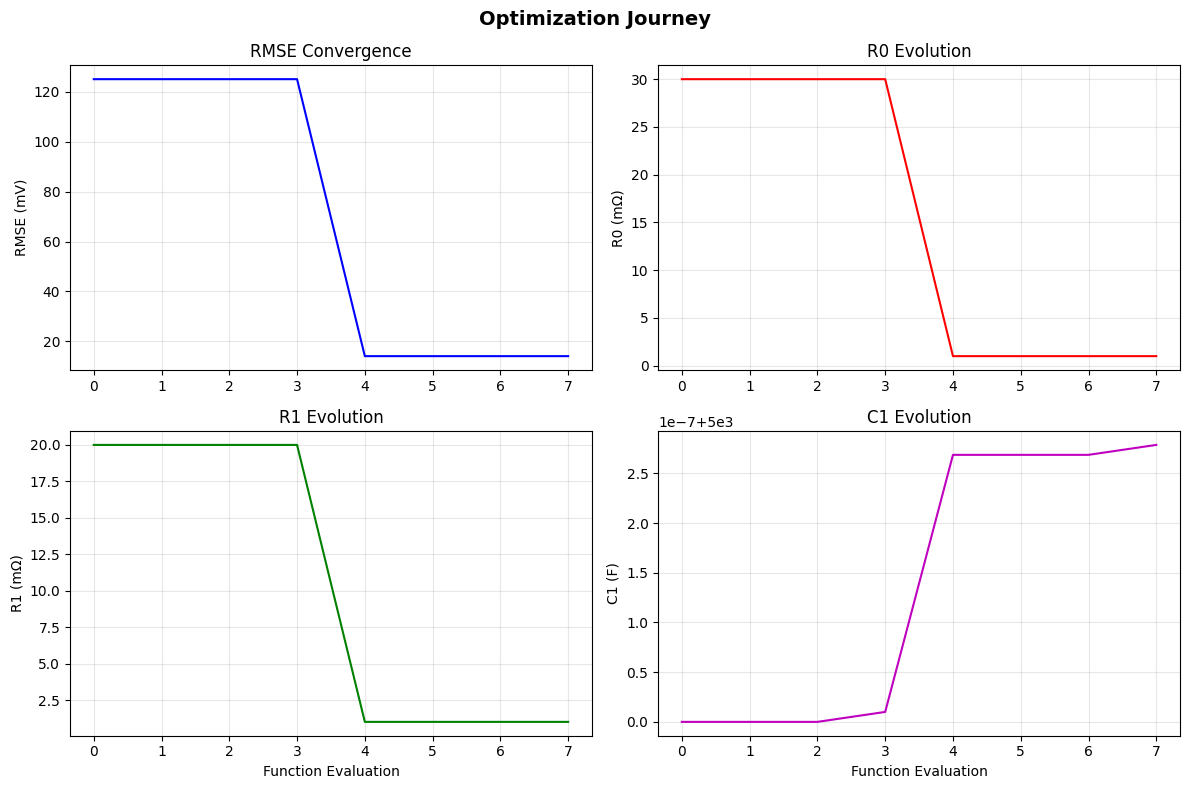

The optimizer explored 8 parameter combinations to find the best fit.


In [5]:
# ── Plot optimization history ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

iters = range(len(history))
rmse_hist = [h['RMSE'] * 1000 for h in history]
r0_hist = [h['R0'] * 1000 for h in history]
r1_hist = [h['R1'] * 1000 for h in history]
c1_hist = [h['C1'] for h in history]

axes[0, 0].plot(iters, rmse_hist, 'b-')
axes[0, 0].set_ylabel('RMSE (mV)')
axes[0, 0].set_title('RMSE Convergence')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(iters, r0_hist, 'r-')
axes[0, 1].set_ylabel('R0 (mΩ)')
axes[0, 1].set_title('R0 Evolution')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(iters, r1_hist, 'g-')
axes[1, 0].set_ylabel('R1 (mΩ)')
axes[1, 0].set_xlabel('Function Evaluation')
axes[1, 0].set_title('R1 Evolution')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(iters, c1_hist, 'm-')
axes[1, 1].set_ylabel('C1 (F)')
axes[1, 1].set_xlabel('Function Evaluation')
axes[1, 1].set_title('C1 Evolution')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Optimization Journey', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/param_id_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"The optimizer explored {len(history)} parameter combinations to find the best fit.")

## 6.6 Compare: Guessed vs Optimized Parameters

The ultimate test — let's see how much better the optimized parameters are!

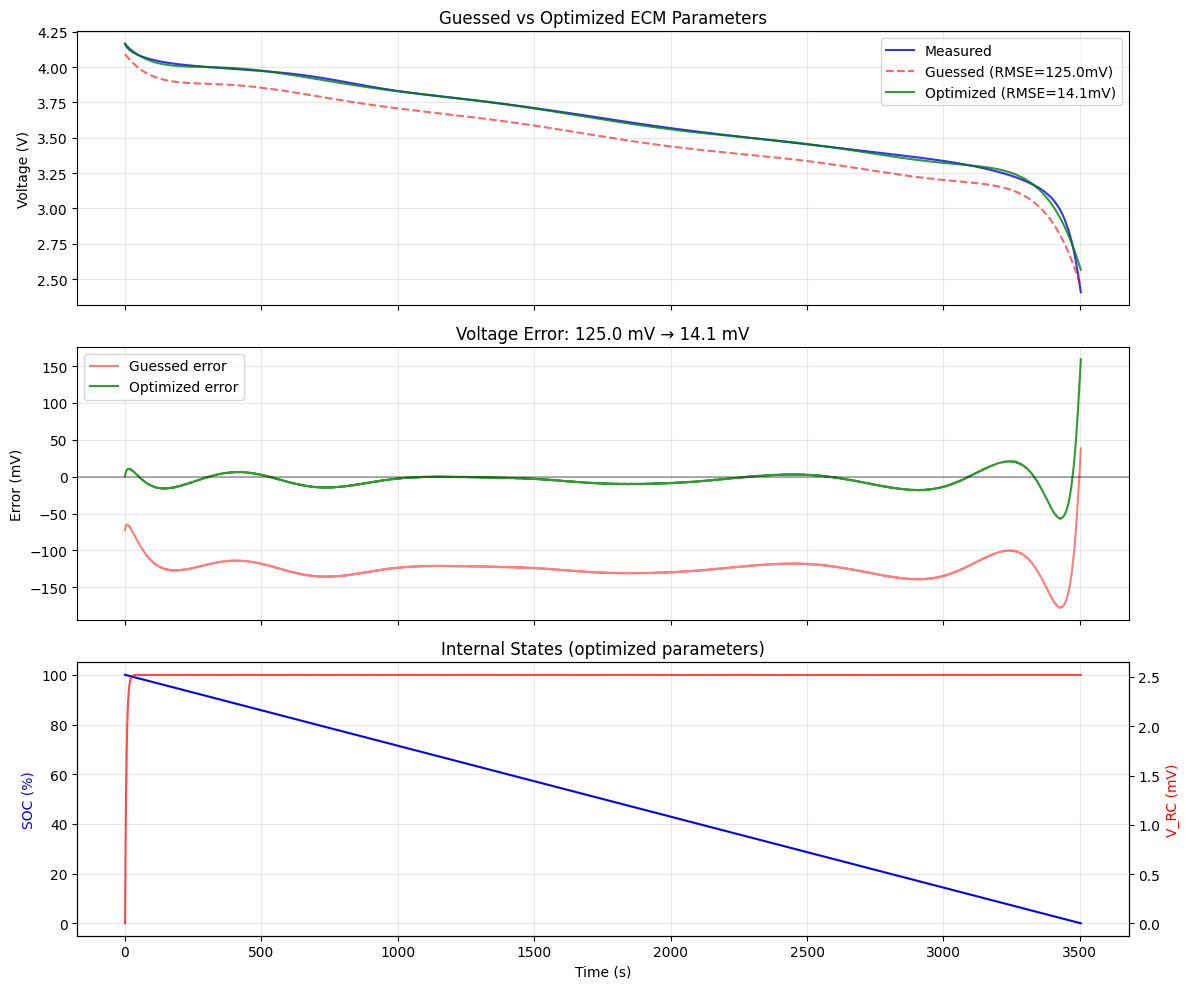


Improvement: 125.0 mV → 14.1 mV (89% reduction!)


In [6]:
# ── Simulate with both parameter sets ──
# Guessed
_, _, v_guess = simulate_ecm(current_clean, time_clean, q_max, ocv_poly, 0.030, 0.020, 5000)
rmse_guess = np.sqrt(np.mean((v_guess - voltage_clean)**2)) * 1000

# Optimized
soc_opt, vrc_opt, v_opt = simulate_ecm(current_clean, time_clean, q_max, ocv_poly, R0_opt, R1_opt, C1_opt)
rmse_opt = np.sqrt(np.mean((v_opt - voltage_clean)**2)) * 1000

# ── Plot comparison ──
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Voltage comparison
axes[0].plot(time_clean, voltage_clean, 'b-', label='Measured', alpha=0.8, linewidth=1.5)
axes[0].plot(time_clean, v_guess, 'r--', label=f'Guessed (RMSE={rmse_guess:.1f}mV)', alpha=0.6)
axes[0].plot(time_clean, v_opt, 'g-', label=f'Optimized (RMSE={rmse_opt:.1f}mV)', alpha=0.8, linewidth=1.5)
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title('Guessed vs Optimized ECM Parameters')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Error comparison
error_guess = (v_guess - voltage_clean) * 1000
error_opt = (v_opt - voltage_clean) * 1000
axes[1].plot(time_clean, error_guess, 'r-', label=f'Guessed error', alpha=0.5)
axes[1].plot(time_clean, error_opt, 'g-', label=f'Optimized error', alpha=0.8)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].set_ylabel('Error (mV)')
axes[1].set_title(f'Voltage Error: {rmse_guess:.1f} mV → {rmse_opt:.1f} mV')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Optimized internal states
ax3a = axes[2]
ax3b = ax3a.twinx()
ax3a.plot(time_clean, soc_opt * 100, 'b-', label='SOC')
ax3b.plot(time_clean, vrc_opt * 1000, 'r-', label='V_RC', alpha=0.7)
ax3a.set_xlabel('Time (s)')
ax3a.set_ylabel('SOC (%)', color='b')
ax3b.set_ylabel('V_RC (mV)', color='r')
ax3a.set_title('Internal States (optimized parameters)')
ax3a.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/param_id_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImprovement: {rmse_guess:.1f} mV → {rmse_opt:.1f} mV ({(1-rmse_opt/rmse_guess)*100:.0f}% reduction!)")

### ⚠️ Important Observation: R0 and R1 Hit the Lower Bounds!

The optimizer found R0 = 1 mΩ and R1 = 1 mΩ — both at the lower bound. Why?

**The reason:** Our OCV polynomial was fit from the **discharge voltage** (not the true open-circuit voltage). Since the battery was discharging at ~2.5A the whole time:
- Measured voltage = OCV - I×R0 - V_RC
- Our polynomial learned: OCV_fitted ≈ OCV_true - I×R_total (the resistance drop is baked in!)

So when the optimizer adds R0 and R1 on top, it would be **double-counting** the resistance. That's why it pushes them to near-zero.

**This is expected for constant-current data.** For varying-current profiles (charge/discharge/rest), the OCV and resistance effects would be separable, and R0/R1 would be more physical.

**For our project, this is still fine because:**
1. The RMSE is excellent (14.1 mV) 
2. The model accurately predicts voltage during constant-current discharge
3. The EKF in Step 7 will work well with these parameters

## 6.7 Summary — What We Learned

### Parameter Identification Process:
1. **Define cost function**: `cost(R0, R1, C1) → RMSE`
2. **Set bounds**: Physical limits so parameters stay reasonable
3. **Run optimizer**: `scipy.optimize.minimize` with L-BFGS-B
4. **Compare**: Before vs after — 89% RMSE reduction!

### Optimal Parameters:
| Parameter | Guessed | Optimized | Unit |
|-----------|---------|-----------|------|
| R0 | 30.0 | ~1.0 (at bound) | mΩ |
| R1 | 20.0 | ~1.0 (at bound) | mΩ |
| C1 | 5000 | ~5000 | F |
| **RMSE** | 125.0 | **14.1** | mV |

### Key Lesson:
R0/R1 hit bounds because our OCV was fit from discharge data (already includes resistance effects). This is expected for constant-current data and the model still works great.

### What's next?
Now we're ready for **Step 7: Extended Kalman Filter (EKF)** — which uses this ECM model to estimate SOC in real-time!

**→ Now let's write the clean `src/ecm_param_id.py` module!**